# 03 - Fairness Mitigation on BERT (Deprecated)

This notebook applies and compares three mitigation settings on the same data split:

1. **Reweighting** (importance weights with max-rule aggregation)
2. **Fair representation learning** (adversarial identity head + gradient reversal)
3. **Reweighting + fair representation learning**

Evaluation uses the same tooling from `01_bias_metrics.ipynb` (`FairnessBiasEvaluator`).

## Method Principles (Short)

### 1) Reweighting (Pre-processing)
Reweighting changes each training example's contribution to the loss. Samples mentioning under-represented identities receive larger weights, while over-represented ones receive smaller weights. In this notebook, per-identity weights are computed from mention-frequency imbalance, and per-comment weight uses **max-rule aggregation** over mentioned identities.

### 2) Fair Representation Learning (In-processing)
We learn representations that are predictive for toxicity but less informative about identity presence. The model uses a shared BERT encoder with:
- a toxicity head (main task), and
- an identity head trained adversarially through **Gradient Reversal Layer (GRL)**.

GRL flips gradients from the identity head before they reach the encoder, encouraging identity-invariant latent features.

### 3) Reweighting + Fair Representation Learning
This combines the two mechanisms:
- data-level correction (reweighting), and
- representation-level debiasing (adversarial learning).

In practice, toxicity loss is reweighted, while the adversarial identity loss is added with coefficient `LAMBDA_ADV`.

### 4) Evaluation Logic
We reuse `FairnessBiasEvaluator` from `01_bias_metrics.ipynb` to compute subgroup fairness metrics (e.g., subgroup AUC variants, DP-related views) on the **same fixed split** from `split_ids.json` for strict comparability across methods.


In [17]:
# Optional install cell (uncomment on Colab/Kaggle)
# !pip -q install "transformers>=4.40,<5" "datasets>=2.19,<3" "accelerate>=0.30" \
#                 "scikit-learn>=1.4" "pandas>=2.2" "numpy>=2,<3" "matplotlib" "seaborn" \
#                 "pyarrow" "tqdm"

In [18]:
import json
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset
from sklearn.metrics import roc_auc_score
from torch.autograd import Function
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

from fairness_jigsaw.metrics import DEFAULT_IDENTITY_COLUMNS, FairnessBiasEvaluator

warnings.filterwarnings("ignore")
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("USE_TORCH", "1")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

HAS_CUDA = torch.cuda.is_available()
HAS_MPS = bool(getattr(torch.backends, "mps", None)) and torch.backends.mps.is_available()
DEVICE = "cuda" if HAS_CUDA else "mps" if HAS_MPS else "cpu"

print(f"Device: {DEVICE}")
if HAS_CUDA:
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
elif HAS_MPS:
    print("MPS   : Apple Metal backend is available")
print(f"Torch : {torch.__version__}")

Device: mps
MPS   : Apple Metal backend is available
Torch : 2.11.0


In [19]:
# Paths
DATA_DIR = Path(os.environ.get("JIGSAW_DATA_DIR", "../data")).expanduser().resolve()
TRAIN_CSV = DATA_DIR / "train.csv"
SPLIT_JSON = DATA_DIR / "split_ids.json"

REPORTS_DIR = Path("../reports").resolve()
OUT_DIR = REPORTS_DIR / "mitigation_bert"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("../models").resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"TRAIN_CSV : {TRAIN_CSV} | exists={TRAIN_CSV.exists()}")
print(f"SPLIT_JSON: {SPLIT_JSON} | exists={SPLIT_JSON.exists()}")
print(f"OUT_DIR   : {OUT_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")

# Core config
SEED = 1337
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_EVAL = 64
N_EPOCHS = 1
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
FP16 = True

LABEL_THRESHOLD = 0.5
IDENTITY_THRESHOLD = 0.5

# Set N_ROWS for faster smoke runs (None = full data)
N_ROWS = 300_000

# Adversarial weight for fair representation learning
LAMBDA_ADV = 0.1

# Backbone freezing: freeze BERT embeddings + first FREEZE_N_LAYERS transformer blocks.
# -1 = freeze all transformer layers (only classification/adversarial heads are trained).
# 0  = freeze embeddings only.
# 10 = freeze embeddings + first 10 of 12 blocks (train only the top 2 + heads).
# Reducing trainable parameters cuts GPU memory and wall-clock time per step
# with minimal accuracy loss when the task is similar to BERT's pretraining domain.
FREEZE_N_LAYERS = 10

TRAIN_CSV : /Users/albert/Desktop/AI-Fairness-Jigsaw/data/train.csv | exists=True
SPLIT_JSON: /Users/albert/Desktop/AI-Fairness-Jigsaw/data/split_ids.json | exists=True
OUT_DIR   : /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert
MODELS_DIR: /Users/albert/Desktop/AI-Fairness-Jigsaw/models


In [20]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if HAS_CUDA:
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

IDENTITY_COLS = list(DEFAULT_IDENTITY_COLUMNS)

# Keep test fairness evaluation on the same 8 identities used in baseline reporting.
TEST_IDENTITY_COLS = [
    "black",
    "homosexual_gay_or_lesbian",
    "white",
    "muslim",
    "jewish",
    "female",
    "christian",
    "male",
]

USE_COLS = ["id", "comment_text", "target"] + IDENTITY_COLS

In [21]:
assert TRAIN_CSV.exists(), f"Missing file: {TRAIN_CSV}"
assert SPLIT_JSON.exists(), f"Missing file: {SPLIT_JSON}"

print("Loading data...")
df = pd.read_csv(TRAIN_CSV, usecols=USE_COLS)
if N_ROWS is not None and N_ROWS < len(df):
    df = df.sample(n=N_ROWS, random_state=SEED).reset_index(drop=True)

# Binary labels
for c in IDENTITY_COLS:
    df[c + "_bin"] = (df[c].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
df["label"] = (df["target"].fillna(0) >= LABEL_THRESHOLD).astype(int)
df["any_identity"] = df[[c + "_bin" for c in IDENTITY_COLS]].max(axis=1)

with open(SPLIT_JSON, "r", encoding="utf-8") as f:
    split_payload = json.load(f)

split_ids = {k: set(split_payload[k]) for k in ["train", "val", "test"]}

train_df = df[df["id"].isin(split_ids["train"])].copy().reset_index(drop=True)
val_df = df[df["id"].isin(split_ids["val"])].copy().reset_index(drop=True)
test_df = df[df["id"].isin(split_ids["test"])].copy().reset_index(drop=True)


print(f"Loaded rows: {len(df):,}")
print(f"train={len(train_df):,} val={len(val_df):,} test={len(test_df):,}")
print(f"toxic rate in train: {train_df['label'].mean():.4f}")

Loading data...
Loaded rows: 300,000
train=239,922 val=29,898 test=30,180
toxic rate in train: 0.0803


In [22]:
# Reweighting from 00_eda_fairness.ipynb:
# per-identity importance weights + per-comment max-rule aggregation.
def compute_importance_weights(train_df: pd.DataFrame, identity_cols: list[str]) -> tuple[pd.DataFrame, np.ndarray]:
    p_train = {col: train_df[f"{col}_bin"].mean() for col in identity_cols}
    mean_mention_rate = np.mean(list(p_train.values()))
    p_target = {col: mean_mention_rate for col in identity_cols}

    records = []
    for col in identity_cols:
        pt = p_train[col]
        # If an identity never appears in the reduced split, keep neutral weight.
        w = 1.0 if pt <= 0 else p_target[col] / pt
        records.append({
            "identity": col,
            "p_train": pt,
            "p_target": p_target[col],
            "importance_weight": w,
        })
    iw_df = pd.DataFrame(records).sort_values("importance_weight", ascending=False).reset_index(drop=True)

    identity_to_w = {r["identity"]: r["importance_weight"] for r in records}
    w_array = np.array([identity_to_w[c] for c in identity_cols], dtype=np.float32)
    w_array = np.nan_to_num(w_array, nan=1.0, posinf=1.0, neginf=1.0)
    w_array = np.clip(w_array, 0.1, 10.0)

    bin_mat = train_df[[f"{c}_bin" for c in identity_cols]].to_numpy(dtype=np.float32)
    has_identity = bin_mat.max(axis=1) > 0
    per_comment_w = np.where(has_identity, (bin_mat * w_array).max(axis=1), 1.0).astype(np.float32)
    per_comment_w = np.nan_to_num(per_comment_w, nan=1.0, posinf=1.0, neginf=1.0)
    return iw_df, per_comment_w

iw_df, train_weights = compute_importance_weights(train_df, IDENTITY_COLS)
print(iw_df.head(10))
print(pd.Series(train_weights).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

                              identity   p_train  p_target  importance_weight
0                         other_gender  0.000004  0.005496        1318.666667
1             other_sexual_orientation  0.000004  0.005496        1318.666667
2                  physical_disability  0.000008  0.005496         659.333333
3  intellectual_or_learning_disability  0.000063  0.005496          87.911111
4                       other_religion  0.000167  0.005496          32.966667
5                             bisexual  0.000200  0.005496          27.472222
6                                hindu  0.000258  0.005496          21.268817
7              other_race_or_ethnicity  0.000292  0.005496          18.838095
8                             buddhist  0.000296  0.005496          18.572770
9                              atheist  0.000729  0.005496           7.535238
count    239922.000000
mean          0.981710
std           0.473342
min           0.183046
25%           1.000000
50%           1.000000
75% 

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def build_dataset(d: pd.DataFrame, include_weight: bool, include_identity: bool) -> Dataset:
    data = {
        "text": d["comment_text"].fillna("").astype(str).tolist(),
        "labels": d["label"].astype(np.float32).tolist(),
    }
    if include_weight:
        data["sample_weight"] = d["sample_weight"].astype(np.float32).tolist()
    if include_identity:
        data["identity_label"] = d["any_identity"].astype(np.float32).tolist()

    ds = Dataset.from_dict(data)

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

    ds = ds.map(tokenize, batched=True, remove_columns=["text"], desc="tokenize")
    ds.set_format("torch")
    return ds

In [24]:
class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        sample_weight = inputs.pop("sample_weight", None)
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)

        if sample_weight is not None:
            sample_weight = sample_weight.float()
            per_sample = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
            loss = (per_sample * sample_weight).mean()
        else:
            loss = F.binary_cross_entropy_with_logits(logits, labels)

        return (loss, outputs) if return_outputs else loss


class GradReverseFn(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, lambd=1.0):
        super().__init__()
        self.lambd = lambd

    def forward(self, x):
        return GradReverseFn.apply(x, self.lambd)


class BertAdversarialClassifier(nn.Module):
    def __init__(self, model_name: str, lambd: float = 1.0):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(self.encoder.config.hidden_dropout_prob)
        self.tox_head = nn.Linear(hidden, 1)
        self.grl = GradientReversal(lambd=lambd)
        self.id_head = nn.Linear(hidden, 1)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        tox_logits = self.tox_head(cls).squeeze(-1)
        id_logits = self.id_head(self.grl(cls)).squeeze(-1)
        return {
            "logits": tox_logits.unsqueeze(-1),
            "toxicity_logits": tox_logits,
            "identity_logits": id_logits,
        }


class AdversarialTrainer(Trainer):
    def __init__(self, *args, lambda_adv: float = 0.1, use_sample_weight: bool = False, **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_adv = lambda_adv
        self.use_sample_weight = use_sample_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        identity_label = inputs.pop("identity_label").float()
        sample_weight = inputs.pop("sample_weight", None)

        outputs = model(**inputs)
        tox_logits = outputs["toxicity_logits"]
        id_logits = outputs["identity_logits"]

        tox_loss_vec = F.binary_cross_entropy_with_logits(tox_logits, labels, reduction="none")
        if self.use_sample_weight and sample_weight is not None:
            tox_loss = (tox_loss_vec * sample_weight.float()).mean()
        else:
            tox_loss = tox_loss_vec.mean()

        id_loss = F.binary_cross_entropy_with_logits(id_logits, identity_label)
        loss = tox_loss + self.lambda_adv * id_loss
        return (loss, outputs) if return_outputs else loss

In [25]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


@torch.inference_mode()
def predict_proba(model, texts, *, max_length, batch_size=64):
    model.to(DEVICE).eval()
    all_logits = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i + batch_size],
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**enc)
        # BertAdversarialClassifier returns a plain dict with "toxicity_logits";
        # AutoModelForSequenceClassification returns a ModelOutput with "logits".
        if isinstance(out, dict) and "toxicity_logits" in out:
            logits = out["toxicity_logits"]
        else:
            logits = out.logits.squeeze(-1)
        all_logits.append(logits.detach().cpu().numpy())

    logits = np.concatenate(all_logits, axis=0)
    return sigmoid(logits)


def make_training_args(run_name: str) -> TrainingArguments:
    extra_args = {}
    # Keep compatibility across transformers versions.
    if "use_mps_device" in getattr(TrainingArguments, "__dataclass_fields__", {}):
        extra_args["use_mps_device"] = HAS_MPS

    return TrainingArguments(
        output_dir=str(OUT_DIR / run_name),
        num_train_epochs=N_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE_TRAIN,
        per_device_eval_batch_size=BATCH_SIZE_EVAL,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        fp16=FP16 and HAS_CUDA,
        bf16=False,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=False,
        report_to=[],
        seed=SEED,
        remove_unused_columns=False,
        **extra_args,
    )

In [26]:
def freeze_bert_backbone(model: nn.Module, n_freeze_layers: int = -1) -> None:
    """Freeze BERT embeddings and the first *n_freeze_layers* transformer blocks.

    Args:
        model: AutoModelForSequenceClassification (has .bert) or
               BertAdversarialClassifier (has .encoder).
        n_freeze_layers: Number of transformer blocks to freeze.
            -1  → freeze all 12 blocks (only heads remain trainable).
             0  → freeze embeddings only, all transformer blocks trainable.
             N  → freeze embeddings + blocks 0..N-1; blocks N..11 trainable.
    """
    # Resolve the underlying BertModel regardless of wrapper class
    encoder = model.bert if hasattr(model, "bert") else model.encoder

    # Embeddings are always frozen — they rarely benefit from task fine-tuning
    for param in encoder.embeddings.parameters():
        param.requires_grad = False

    layers = encoder.encoder.layer
    n_total = len(layers)
    n_freeze = n_total if n_freeze_layers < 0 else min(n_freeze_layers, n_total)

    for layer in layers[:n_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = n_freeze if n_freeze_layers >= 0 else n_total
    print(f"  Frozen: embeddings + {frozen}/{n_total} transformer blocks")
    print(f"  Trainable params: {trainable:,} / {total:,} ({trainable / total:.1%})")

In [27]:
import gc

train_df = train_df.copy()
train_df["sample_weight"] = train_weights
train_df["sample_weight"] = pd.to_numeric(train_df["sample_weight"], errors="coerce")
invalid_sw = ~np.isfinite(train_df["sample_weight"].to_numpy())
if invalid_sw.any():
    print(f"Warning: fixing {int(invalid_sw.sum())} invalid sample weights to 1.0")
    train_df.loc[invalid_sw, "sample_weight"] = 1.0

evaluator = FairnessBiasEvaluator(
    identity_cols=TEST_IDENTITY_COLS,
    toxicity_threshold=LABEL_THRESHOLD,
    identity_threshold=IDENTITY_THRESHOLD,
)

texts_test = test_df["comment_text"].fillna("").astype(str).tolist()
variant_outputs = {}

# Confirm the device that will be used for training and inference
print(f"Active device: {DEVICE}")
if DEVICE == "cpu":
    import warnings
    warnings.warn("No GPU/MPS detected — training will be very slow on CPU.")

# Pre-tokenise val once per identity-label layout to avoid redundant work
val_ds_plain    = build_dataset(val_df, include_weight=False, include_identity=False)
val_ds_identity = build_dataset(val_df, include_weight=False, include_identity=True)

variants = [
    "reweighting",
    "fair_representation_learning",
    "reweighting_plus_fair_representation_learning",
]

for variant in variants:
    print("=" * 80)
    print(f"Training variant: {variant}  [device={DEVICE}]")

    if variant == "reweighting":
        train_ds = build_dataset(train_df, include_weight=True, include_identity=False)
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)
        # Head-only: freeze the entire backbone, unfreeze only the linear classifier.
        # Reweighting corrects for identity-mention imbalance at the data level;
        # the BERT representations themselves need not change.
        for param in model.parameters():
            param.requires_grad = False
        for param in model.classifier.parameters():
            param.requires_grad = True
        total     = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Head-only — trainable: {trainable:,} / {total:,} ({trainable / total:.1%})")
        trainer = WeightedBCETrainer(
            model=model,
            args=make_training_args(variant),
            train_dataset=train_ds,
            eval_dataset=val_ds_plain,
        )

    elif variant == "fair_representation_learning":
        train_ds = build_dataset(train_df, include_weight=False, include_identity=True)
        model = BertAdversarialClassifier(MODEL_NAME, lambd=1.0)
        freeze_bert_backbone(model, FREEZE_N_LAYERS)
        trainer = AdversarialTrainer(
            model=model,
            args=make_training_args(variant),
            train_dataset=train_ds,
            eval_dataset=val_ds_identity,
            lambda_adv=LAMBDA_ADV,
            use_sample_weight=False,
        )

    else:  # reweighting + fair representation learning
        train_ds = build_dataset(train_df, include_weight=True, include_identity=True)
        model = BertAdversarialClassifier(MODEL_NAME, lambd=1.0)
        freeze_bert_backbone(model, FREEZE_N_LAYERS)
        trainer = AdversarialTrainer(
            model=model,
            args=make_training_args(variant),
            train_dataset=train_ds,
            eval_dataset=val_ds_identity,
            lambda_adv=LAMBDA_ADV,
            use_sample_weight=True,
        )

    trainer.train()

    # Evaluate immediately so we never hold more than one model in memory
    print("-" * 80)
    print(f"Evaluating: {variant}")
    probs = predict_proba(model, texts_test, max_length=MAX_LEN, batch_size=BATCH_SIZE_EVAL)

    eval_df = test_df[["id", "label"] + TEST_IDENTITY_COLS].copy()
    eval_df["pred_prob"] = pd.to_numeric(pd.Series(probs), errors="coerce")

    valid_mask = np.isfinite(eval_df["pred_prob"].to_numpy())
    invalid_count = int((~valid_mask).sum())
    if invalid_count > 0:
        print(f"Warning: dropping {invalid_count} rows with non-finite prediction scores.")

    eval_df_valid = eval_df.loc[valid_mask].copy().reset_index(drop=True)

    if eval_df_valid.empty:
        print("Warning: no valid prediction scores; fairness tables and overall AUC are set to NaN/empty.")
        raw_table = pd.DataFrame()
        normalized_table = pd.DataFrame()
        overall_auc = float("nan")
    else:
        raw_table, _ = evaluator.evaluate(eval_df_valid, score_col="pred_prob", label_col="label")
        normalized_table = evaluator.build_bias_metrics_table(normalize=True)

        y_true = eval_df_valid["label"].to_numpy()
        y_score = eval_df_valid["pred_prob"].to_numpy()
        if np.unique(y_true).size < 2:
            print("Warning: only one class present in valid test labels; overall AUC is set to NaN.")
            overall_auc = float("nan")
        else:
            overall_auc = roc_auc_score(y_true, y_score)

    variant_outputs[variant] = {
        "overall_auc": float(overall_auc),
        "raw_table": raw_table.copy(),
        "normalized_table": normalized_table.copy(),
    }

    print(f"overall_auc: {overall_auc:.5f}")
    display(raw_table.head(10))

    # Save model — move to CPU first so the checkpoint is device-agnostic
    save_dir = MODELS_DIR / variant
    if isinstance(model, BertAdversarialClassifier):
        save_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.cpu().state_dict(), save_dir / "pytorch_model.bin")
        with open(save_dir / "config.json", "w", encoding="utf-8") as f:
            json.dump({"model_name": MODEL_NAME, "lambd": model.grl.lambd}, f)
    else:
        model.save_pretrained(save_dir)
        tokenizer.save_pretrained(save_dir)
    print(f"Saved model: {save_dir}")

    # Release model weights before loading the next variant
    del model, trainer, train_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Active device: mps


tokenize: 100%|██████████| 29898/29898 [00:01<00:00, 18426.29 examples/s]


Training variant: reweighting  [device=mps]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9483.45it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

  Head-only — trainable: 769 / 109,483,009 (0.0%)


...

  Frozen: embeddings + 10/12 transformer blocks
  Trainable params: 14,767,874 / 109,483,778 (13.5%)


Epoch,Training Loss,Validation Loss
1,0.237491,No log


--------------------------------------------------------------------------------
Evaluating: reweighting_plus_fair_representation_learning
overall_auc: 0.94195


,DP Gap,1-Subgroup AUC,1-BPSN AUC,1-BNSP AUC,1-Pinned AUC,KS Statistic,|Mean Diff|,Wasserstein-1,KL Divergence,|Partial r|
identity,,,,,,,,,,
black,0.203911,0.181748,0.217923,0.038472,0.164322,0.618285,0.224408,0.224409,1.011052,0.066470
christian,0.027130,0.082578,0.051238,0.094550,0.077180,0.182572,0.024789,0.024790,0.061478,0.028895
female,0.031741,0.115094,0.094544,0.071322,0.094707,0.195562,0.047318,0.048234,0.109701,0.020210
homosexual_gay_or_lesbian,0.101856,0.191331,0.181091,0.045752,0.152729,0.490831,0.150417,0.152239,0.768358,0.049938
jewish,0.012112,0.108193,0.084352,0.078314,0.090846,0.281503,0.019957,0.027130,0.303400,0.007086
male,0.041167,0.124833,0.105412,0.066501,0.100824,0.256363,0.065016,0.065083,0.170078,0.022132
muslim,0.041625,0.169858,0.132636,0.063931,0.128429,0.410380,0.076561,0.076748,0.350080,0.036541
white,0.118718,0.179866,0.168828,0.057018,0.144772,0.499140,0.150900,0.150904,0.618218,0.055106


Saved model: /Users/albert/Desktop/AI-Fairness-Jigsaw/models/reweighting_plus_fair_representation_learning


## Results

Training, evaluation, and memory cleanup for all three variants are handled in the cell above. `variant_outputs` now contains per-variant AUC, raw fairness table, and normalized fairness table.

Heatmap: reweighting
Heatmap: fair_representation_learning
Heatmap: reweighting_plus_fair_representation_learning


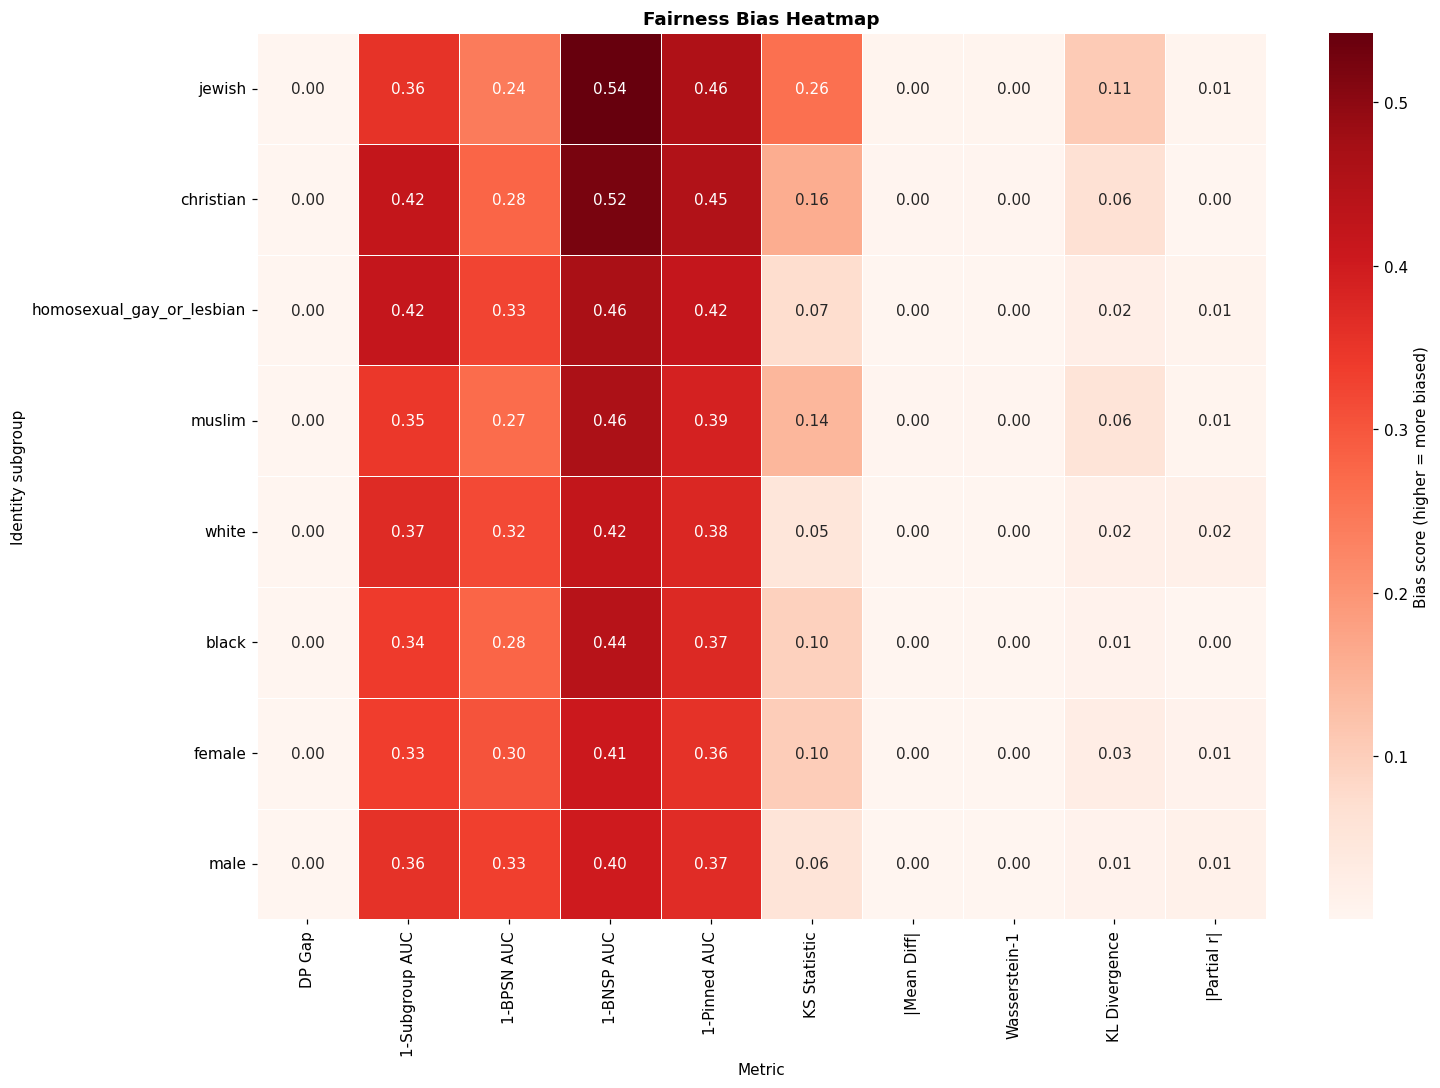

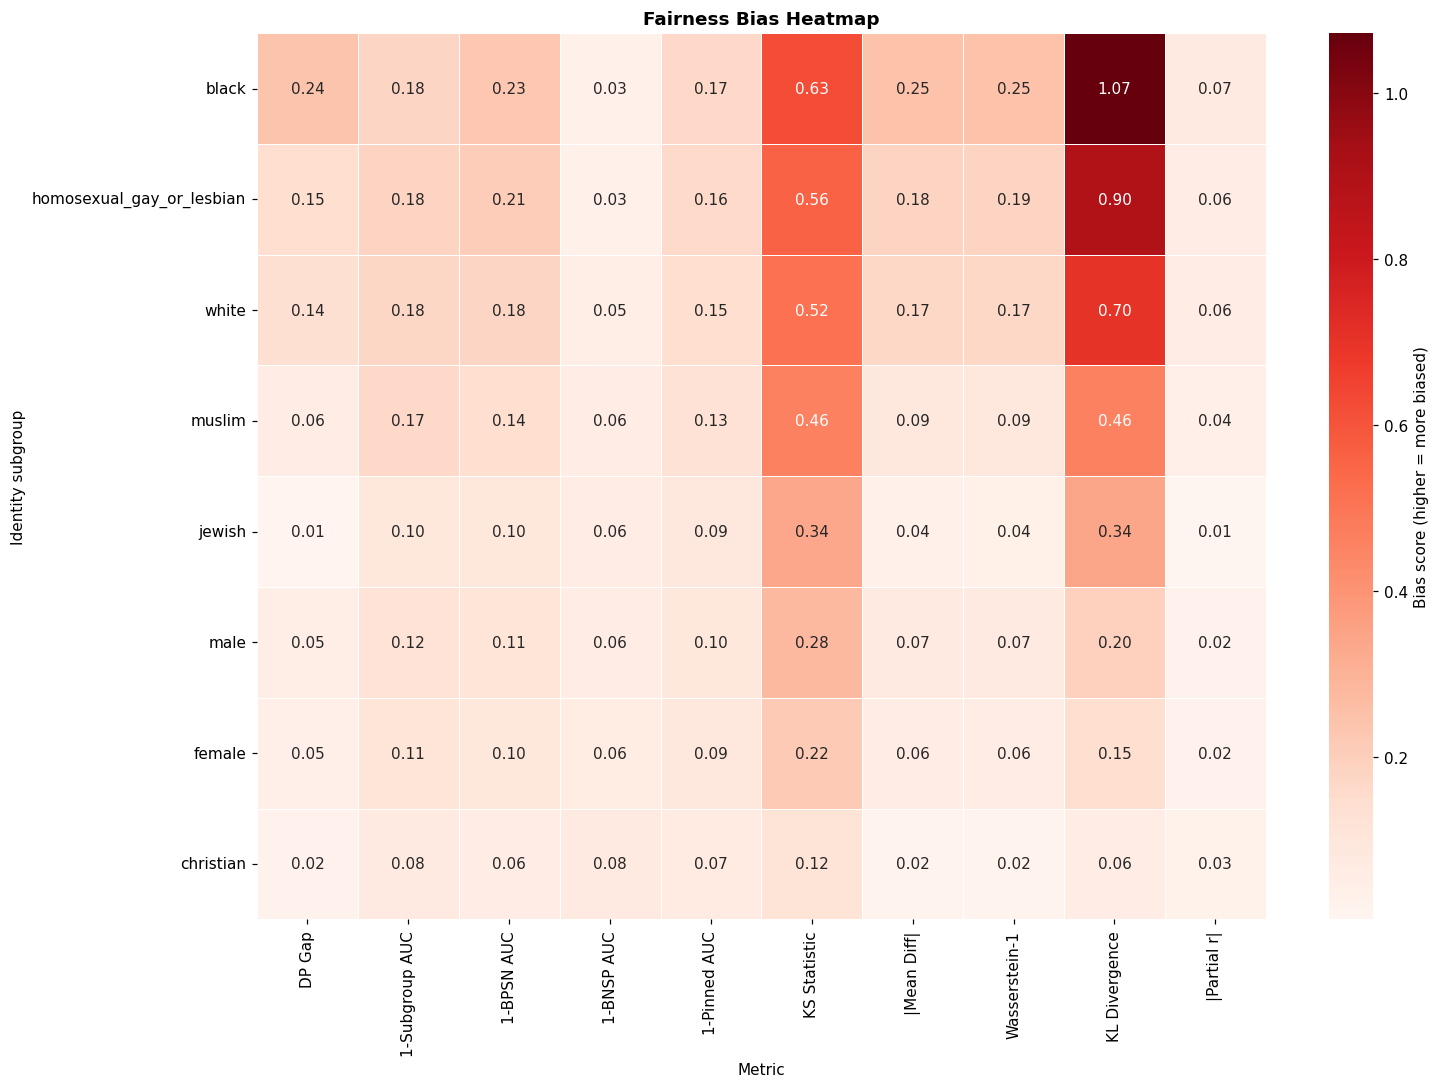

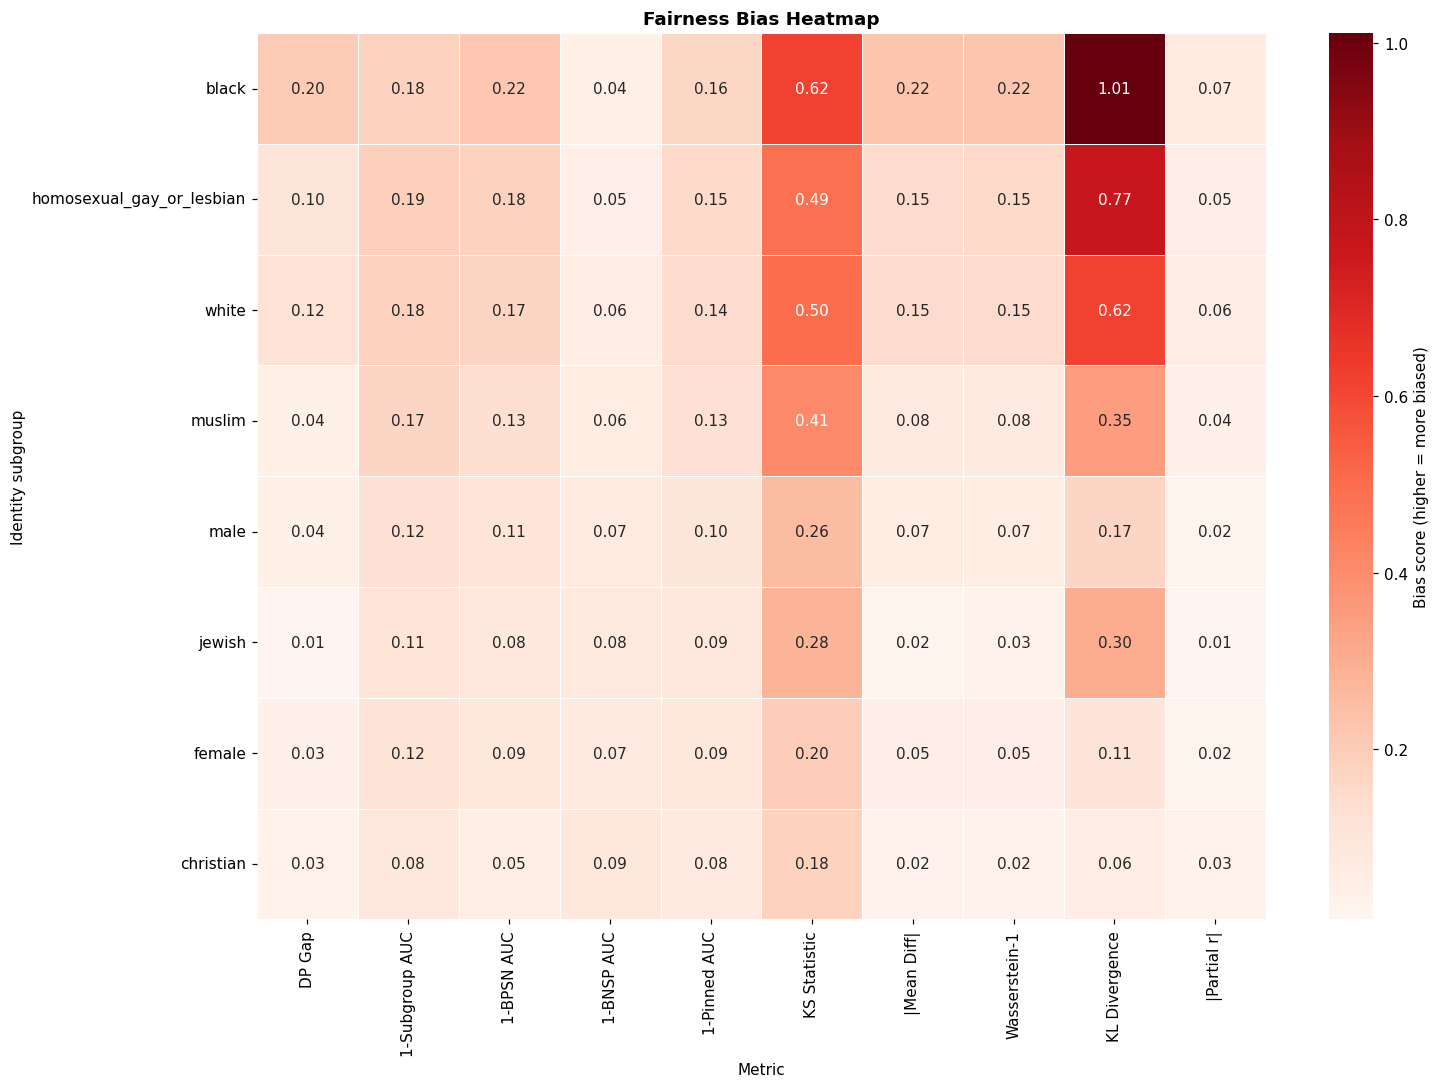

In [34]:
# Visualize fairness heatmaps per variant
for variant, payload in variant_outputs.items():
    print(f"Heatmap: {variant}")
    evaluator.plot_bias_heatmap(payload["raw_table"], normalize=False)

In [36]:
# Compact cross-variant comparison
summary_rows = []
for variant, payload in variant_outputs.items():
    raw_table = payload["raw_table"]
    numeric_cols = [c for c in raw_table.columns if c != "identity"]

    row = {
        "variant": variant,
        "overall_auc": payload["overall_auc"],
    }
    for c in numeric_cols:
        row[f"mean::{c}"] = float(pd.to_numeric(raw_table[c], errors="coerce").mean())
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("variant").reset_index(drop=True)
display(summary_df)

summary_path = OUT_DIR / "variant_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")

,variant,overall_auc,mean::DP Gap,mean::1-Subgroup AUC,mean::1-BPSN AUC,mean::1-BNSP AUC,mean::1-Pinned AUC,mean::KS Statistic,mean::|Mean Diff|,mean::Wasserstein-1,mean::KL Divergence,mean::|Partial r|
0,fair_representation_learning,0.943010,0.090095,0.138944,0.140445,0.054583,0.118950,0.389681,0.109743,0.111161,0.484941,0.039635
1,reweighting,0.626809,0.000066,0.368020,0.293958,0.457502,0.399112,0.117387,0.002265,0.002483,0.039551,0.007457
2,reweighting_plus_fair_representation_learning,0.941946,0.072282,0.144188,0.129503,0.064482,0.119226,0.366830,0.094921,0.096192,0.424046,0.035797


Saved summary to: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/variant_summary.csv


In [31]:
# Save per-variant detailed fairness tables
for variant, payload in variant_outputs.items():
    safe_name = variant.replace(" ", "_")
    raw_path = OUT_DIR / f"{safe_name}_raw_fairness.csv"
    norm_path = OUT_DIR / f"{safe_name}_normalized_fairness.csv"
    payload["raw_table"].to_csv(raw_path, index=False)
    payload["normalized_table"].to_csv(norm_path)
    print(f"Saved: {raw_path}")
    print(f"Saved: {norm_path}")

Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/reweighting_raw_fairness.csv
Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/reweighting_normalized_fairness.csv
Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/fair_representation_learning_raw_fairness.csv
Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/fair_representation_learning_normalized_fairness.csv
Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/reweighting_plus_fair_representation_learning_raw_fairness.csv
Saved: /Users/albert/Desktop/AI-Fairness-Jigsaw/reports/mitigation_bert/reweighting_plus_fair_representation_learning_normalized_fairness.csv


## Notes

- This notebook keeps the split fixed via `data/split_ids.json` for strict comparability.
- `N_EPOCHS`, `N_ROWS`, and `LAMBDA_ADV` are the primary knobs for speed/quality/fairness trade-offs.
- If GPU memory is limited, reduce `BATCH_SIZE_TRAIN` to 8 and optionally set `MAX_LEN=96`.